In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# ── Generate synthetic data in D dimensions ──
np.random.seed(42)

D = 5       # Original high-dimensional space
N = 300     # Number of data points
M = 2       # Target lower-dimensional space (M < D)

# Create data that has most variance along 2 hidden directions
# so PCA should recover a meaningful 2D projection.
hidden = np.random.randn(N, 2)
W_true = np.random.randn(2, D)          # 2 latent directions → D dims
noise  = 0.3 * np.random.randn(N, D)    # small isotropic noise
X = hidden @ W_true + noise              # (N, D)

print(f"Data shape : {X.shape}  (N={N}, D={D})")
print(f"Target dims: M={M}")

Data shape : (300, 5)  (N=300, D=5)
Target dims: M=2


In [3]:
# ── PCA from scratch (eigen-decomposition) ──

# Step 1: Centre the data  (subtract the mean)
mean = X.mean(axis=0)          # (D,)
X_centered = X - mean          # (N, D)

# Step 2: Compute the covariance matrix  S = (1/N) Xᵀ X
S = (X_centered.T @ X_centered) / N   # (D, D)

# Step 3: Eigen-decomposition of S
eigenvalues, eigenvectors = np.linalg.eigh(S)

# eigh returns in ascending order → reverse to get largest first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]    # columns are eigenvectors

print("Eigenvalues (sorted):")
for i, ev in enumerate(eigenvalues):
    print(f"  λ_{i+1} = {ev:.4f}")

# Step 4: Select the top-M eigenvectors  → projection matrix U_M
U_M = eigenvectors[:, :M]             # (D, M)

# Step 5: Project data onto M-dimensional subspace
Z = X_centered @ U_M                  # (N, M)

print(f"\nProjection matrix U_M shape : {U_M.shape}")
print(f"Projected data Z shape      : {Z.shape}")

Eigenvalues (sorted):
  λ_1 = 10.4037
  λ_2 = 3.9325
  λ_3 = 0.1025
  λ_4 = 0.0853
  λ_5 = 0.0796

Projection matrix U_M shape : (5, 2)
Projected data Z shape      : (300, 2)


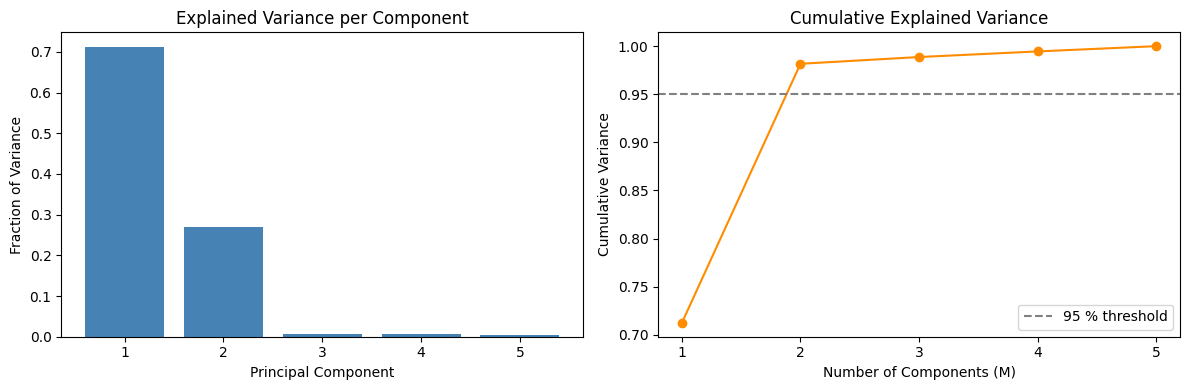


Top 2 components capture 98.2 % of total variance.


In [4]:
# ── Variance explained ──
total_var = eigenvalues.sum()
explained_ratio = eigenvalues / total_var

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of individual explained variance
axes[0].bar(range(1, D + 1), explained_ratio, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Fraction of Variance")
axes[0].set_title("Explained Variance per Component")
axes[0].set_xticks(range(1, D + 1))

# Cumulative explained variance
cumulative = np.cumsum(explained_ratio)
axes[1].plot(range(1, D + 1), cumulative, "o-", color="darkorange")
axes[1].axhline(0.95, ls="--", color="gray", label="95 % threshold")
axes[1].set_xlabel("Number of Components (M)")
axes[1].set_ylabel("Cumulative Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, D + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTop {M} components capture {cumulative[M-1]*100:.1f} % of total variance.")

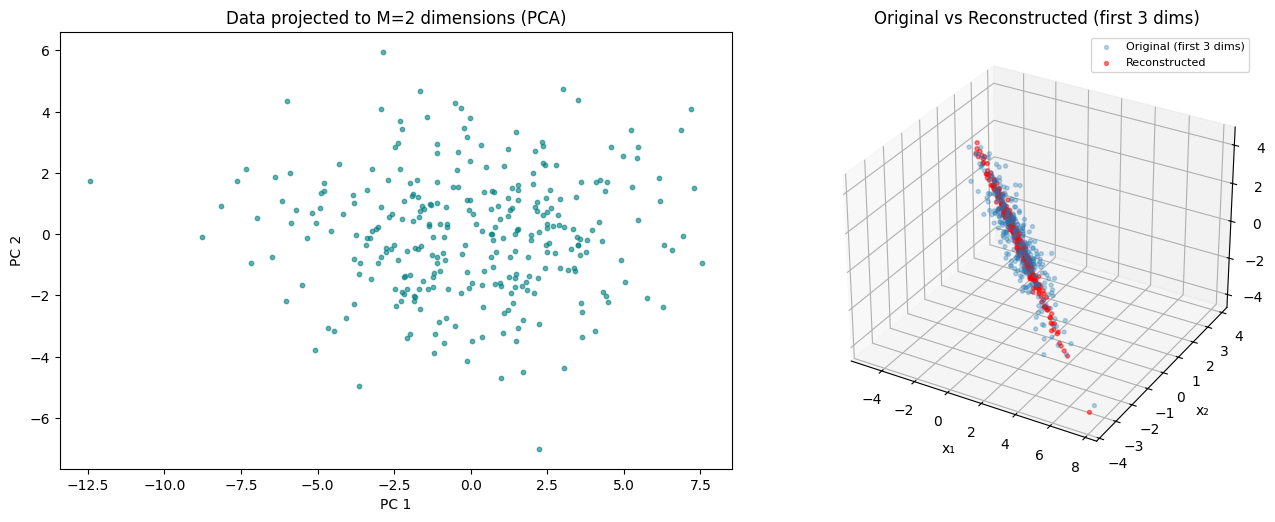

In [5]:
# ── Visualise the M=2 projection ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2-D scatter of the projected data
axes[0].scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.6, c="teal")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].set_title(f"Data projected to M={M} dimensions (PCA)")
axes[0].set_aspect("equal")

# Right: first 3 original dims with projected points back in D-space
X_reconstructed = Z @ U_M.T + mean   # reconstruct back to D dims

ax3d = fig.add_subplot(122, projection="3d")
ax3d.scatter(X[:, 0], X[:, 1], X[:, 2],
             s=8, alpha=0.3, label="Original (first 3 dims)")
ax3d.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], X_reconstructed[:, 2],
             s=8, alpha=0.5, color="red", label="Reconstructed")
ax3d.set_xlabel("x₁"); ax3d.set_ylabel("x₂"); ax3d.set_zlabel("x₃")
ax3d.set_title("Original vs Reconstructed (first 3 dims)")
ax3d.legend(fontsize=8)

axes[1].set_visible(False)   # hide the 2-D axes behind the 3-D subplot
plt.tight_layout()
plt.show()

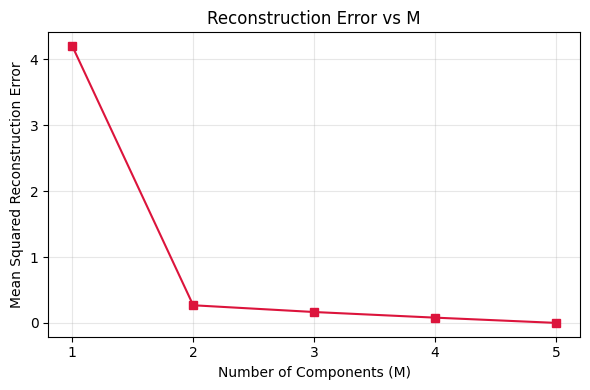

In [6]:
# ── Reconstruction error vs number of components ──
errors = []
for m in range(1, D + 1):
    U_m = eigenvectors[:, :m]
    Z_m = X_centered @ U_m
    X_rec_m = Z_m @ U_m.T
    mse = np.mean(np.sum((X_centered - X_rec_m) ** 2, axis=1))
    errors.append(mse)

plt.figure(figsize=(6, 4))
plt.plot(range(1, D + 1), errors, "s-", color="crimson")
plt.xlabel("Number of Components (M)")
plt.ylabel("Mean Squared Reconstruction Error")
plt.title("Reconstruction Error vs M")
plt.xticks(range(1, D + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()